In [ ]:
import pandas as pd

In [ ]:
rating = pd.read_csv('/content/drive/MyDrive/anime and rating data/rating.csv')
rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [ ]:
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


In [ ]:
anime = pd.read_csv('/content/drive/MyDrive/anime and rating data/anime.csv')
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [ ]:
anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [ ]:
df = pd.merge(rating,anime.drop('rating',axis=1),on='anime_id')
df.head()

,user_id,anime_id,rating,name,genre,type,episodes,members
0,1,20,-1,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220,683297
1,1,24,-1,School Rumble,"Comedy, Romance, School, Shounen",TV,26,178553
2,1,79,-1,Shuffle!,"Comedy, Drama, Ecchi, Fantasy, Harem, Magic, R...",TV,24,158772
3,1,226,-1,Elfen Lied,"Action, Drama, Horror, Psychological, Romance,...",TV,13,623511
4,1,241,-1,Girls Bravo: First Season,"Comedy, Ecchi, Fantasy, Harem, Romance, School",TV,11,84395


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813727 entries, 0 to 7813726
Data columns (total 8 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   user_id   int64 
 1   anime_id  int64 
 2   rating    int64 
 3   name      object
 4   genre     object
 5   type      object
 6   episodes  object
 7   members   int64 
dtypes: int64(4), object(4)
memory usage: 476.9+ MB


In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7813612 entries, 0 to 7813726
Data columns (total 8 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   user_id   int64 
 1   anime_id  int64 
 2   rating    int64 
 3   name      object
 4   genre     object
 5   type      object
 6   episodes  object
 7   members   int64 
dtypes: int64(4), object(4)
memory usage: 536.5+ MB


In [ ]:
duplicate_names = df[df.duplicated(subset=['name'], keep=False)]
if not duplicate_names.empty:
  print("Duplicate names found:")
  print(duplicate_names['name'].unique())
else:
  print("No duplicate names found.")

Duplicate names found:
['Naruto' 'School Rumble' 'Shuffle!' ... 'Grendizer Giga'
 'Lord of Vermillion III Special Anime Movie'
 'Stitch!: Zutto Saikou no Tomodachi Special']


In [ ]:
df.drop_duplicates(subset=['name'], keep='first', inplace=True)

duplicate_names = df[df.duplicated(subset=['name'], keep=False)]
if not duplicate_names.empty:
  print("Duplicate names found:")
  print(duplicate_names['name'].unique())
else:
  print("No duplicate names found.")

No duplicate names found.


In [ ]:
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')

In [ ]:
df['genre'] = df['genre'].astype(str)
df['type'] = df['type'].astype(str)
df['name'] = df['name'].astype(str)

In [ ]:
# Convert rating range to 1 to 10
if 'rating' in df.columns and df['rating'].min() >= 1 and df['rating'].max() <= 10:
  print("Rating range is already within 1 to 10.")
else:
  df['rating'] = (df['rating'] - df['rating'].min()) / (df['rating'].max() - df['rating'].min()) * 9 + 1
  df['rating'] = df['rating'].clip(lower=1, upper=10)

# First, identify the anime with rating 1
rating_one_anime = df[df['rating'] == 1]

# Next, create the equally distributed ratings from 1 to 9
import numpy as np

num_anime_to_convert = rating_one_anime.shape[0]

if num_anime_to_convert > 0:
    new_ratings = np.linspace(1, 9, num_anime_to_convert)

    # Update the rating column for the selected anime
    df.loc[df['rating'] == 1, 'rating'] = new_ratings

    print("Ratings of anime with initial rating 1 have been updated.")
else:
    print("No anime found with rating 1.")

Ratings of anime with initial rating 1 have been updated.


In [ ]:
df['rating'] = df['rating'].astype(int)
df

,user_id,anime_id,rating,name,genre,type,episodes,members
0,1,20,1,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220.0,683297
1,1,24,1,School Rumble,"Comedy, Romance, School, Shounen",TV,26.0,178553
2,1,79,1,Shuffle!,"Comedy, Drama, Ecchi, Fantasy, Harem, Magic, R...",TV,24.0,158772
3,1,226,1,Elfen Lied,"Action, Drama, Horror, Psychological, Romance,...",TV,13.0,623511
4,1,241,1,Girls Bravo: First Season,"Comedy, Ecchi, Fantasy, Harem, Romance, School",TV,11.0,84395
...,...,...,...,...,...,...,...,...
7029142,65682,30450,8,Dr. Slump: Hoyoyo! Arale no Himitsu Dai Koukai...,"Comedy, Sci-Fi, Shounen",Special,1.0,248
7447017,69497,33484,10,Shiroi Zou,"Action, Historical, Kids",Movie,1.0,45
7527337,70463,29481,8,Kakinoki Mokkii,"Fantasy, Kids",Special,1.0,61
7703441,72404,34412,9,Hashiri Hajimeta bakari no Kimi ni,Music,Music,1.0,239


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11163 entries, 0 to 7736687
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   11163 non-null  int64  
 1   anime_id  11163 non-null  int64  
 2   rating    11163 non-null  int64  
 3   name      11163 non-null  object 
 4   genre     11163 non-null  object 
 5   type      11163 non-null  object 
 6   episodes  11159 non-null  float64
 7   members   11163 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 784.9+ KB


In [ ]:
pip install pandas rdflib networkx pykeen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.9/564.9 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 718.4/718.4 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.4/383.4 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import networkx as nx
from pykeen.pipeline import pipeline

INFO:pykeen.utils:Using opt_einsum


In [ ]:
# Step 1: Construct the KG using NetworkX
G = nx.MultiDiGraph()

In [ ]:
# Add nodes and edges for users, anime, and genres
for _, row in df.iterrows():
    user_node = f"user_{row['user_id']}"
    anime_node = f"anime_{row['anime_id']}"

    # Add user-anime relationship (rating edge)
    G.add_edge(user_node, anime_node, relation='rated', rating=row['rating'])

    # Add anime-genre relationship
    for genre in row['genre'].split(', '):
        genre_node = f"genre_{genre}"
        G.add_edge(anime_node, genre_node, relation='belongs_to')

    # Add anime-type relationship
    type_node = f"type_{row['type']}"
    G.add_edge(anime_node, type_node, relation='has_type')

In [ ]:
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

print(f"Is directed: {G.is_directed()}")
print(f"Nodes: {G.nodes()}")
print(f"Edges: {G.edges()}")

Number of nodes: 12887
Number of edges: 56057
Is directed: True
Nodes: ['user_1', 'anime_20', 'genre_Action', 'genre_Comedy', 'genre_Martial Arts', 'genre_Shounen', 'genre_Super Power', 'type_TV', 'anime_24', 'genre_Romance', 'genre_School', 'anime_79', 'genre_Drama', 'genre_Ecchi', 'genre_Fantasy', 'genre_Harem', 'genre_Magic', 'genre_Seinen', 'anime_226', 'genre_Horror', 'genre_Psychological', 'genre_Supernatural', 'anime_241', 'anime_355', 'anime_356', 'anime_442', 'genre_Adventure', 'genre_Historical', 'type_Movie', 'anime_487', 'anime_846', 'anime_936', 'anime_1546', 'anime_1692', 'type_OVA', 'anime_1836', 'anime_2001', 'genre_Mecha', 'genre_Sci-Fi', 'anime_2025', 'genre_Mystery', 'anime_2144', 'anime_2787', 'anime_2993', 'genre_Vampire', 'anime_3455', 'anime_4063', 'anime_4214', 'anime_4224', 'genre_Slice of Life', 'anime_4581', 'anime_4744', 'anime_4898', 'genre_Demons', 'anime_4999', 'anime_5034', 'anime_5277', 'anime_5667', 'anime_5781', 'anime_5958', 'anime_6163', 'type_Speci

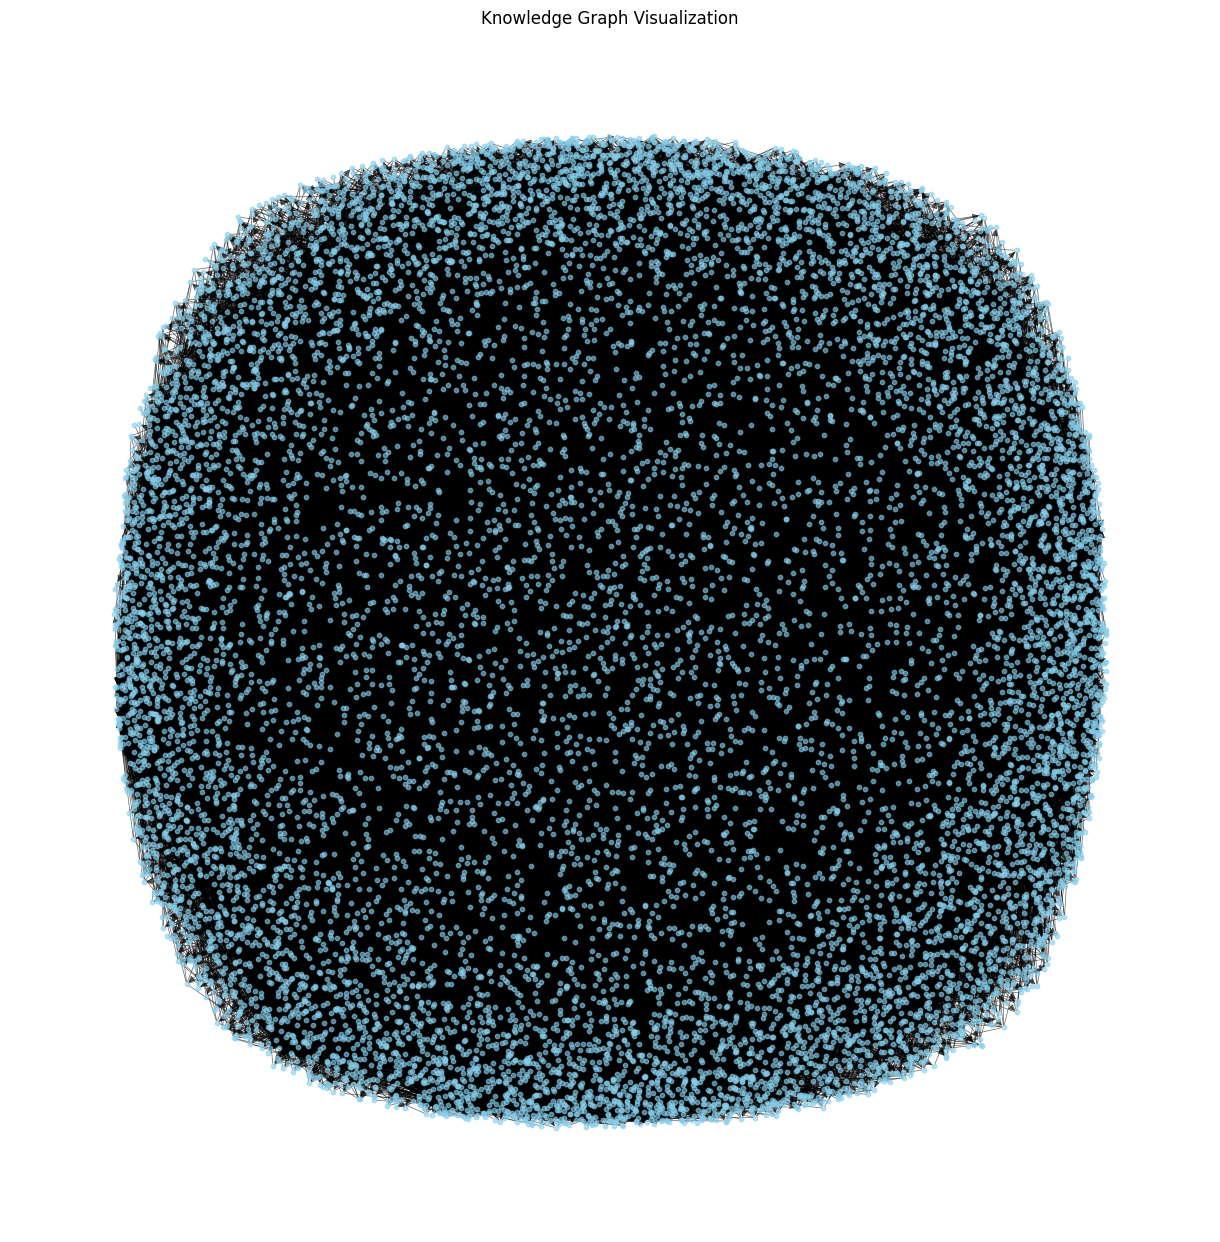

In [ ]:
# prompt: plot entire knowledge graph

import matplotlib.pyplot as plt

# Assuming 'G' is your NetworkX graph from the previous code

plt.figure(figsize=(12, 12))  # Adjust figure size as needed
pos = nx.spring_layout(G, k=0.15, iterations=20) # Adjust k and iterations for better layout
nx.draw(G, pos, with_labels=False, node_size=10, font_size=8, node_color="skyblue", alpha=0.6, width=0.5)
plt.title("Knowledge Graph Visualization")
plt.show()


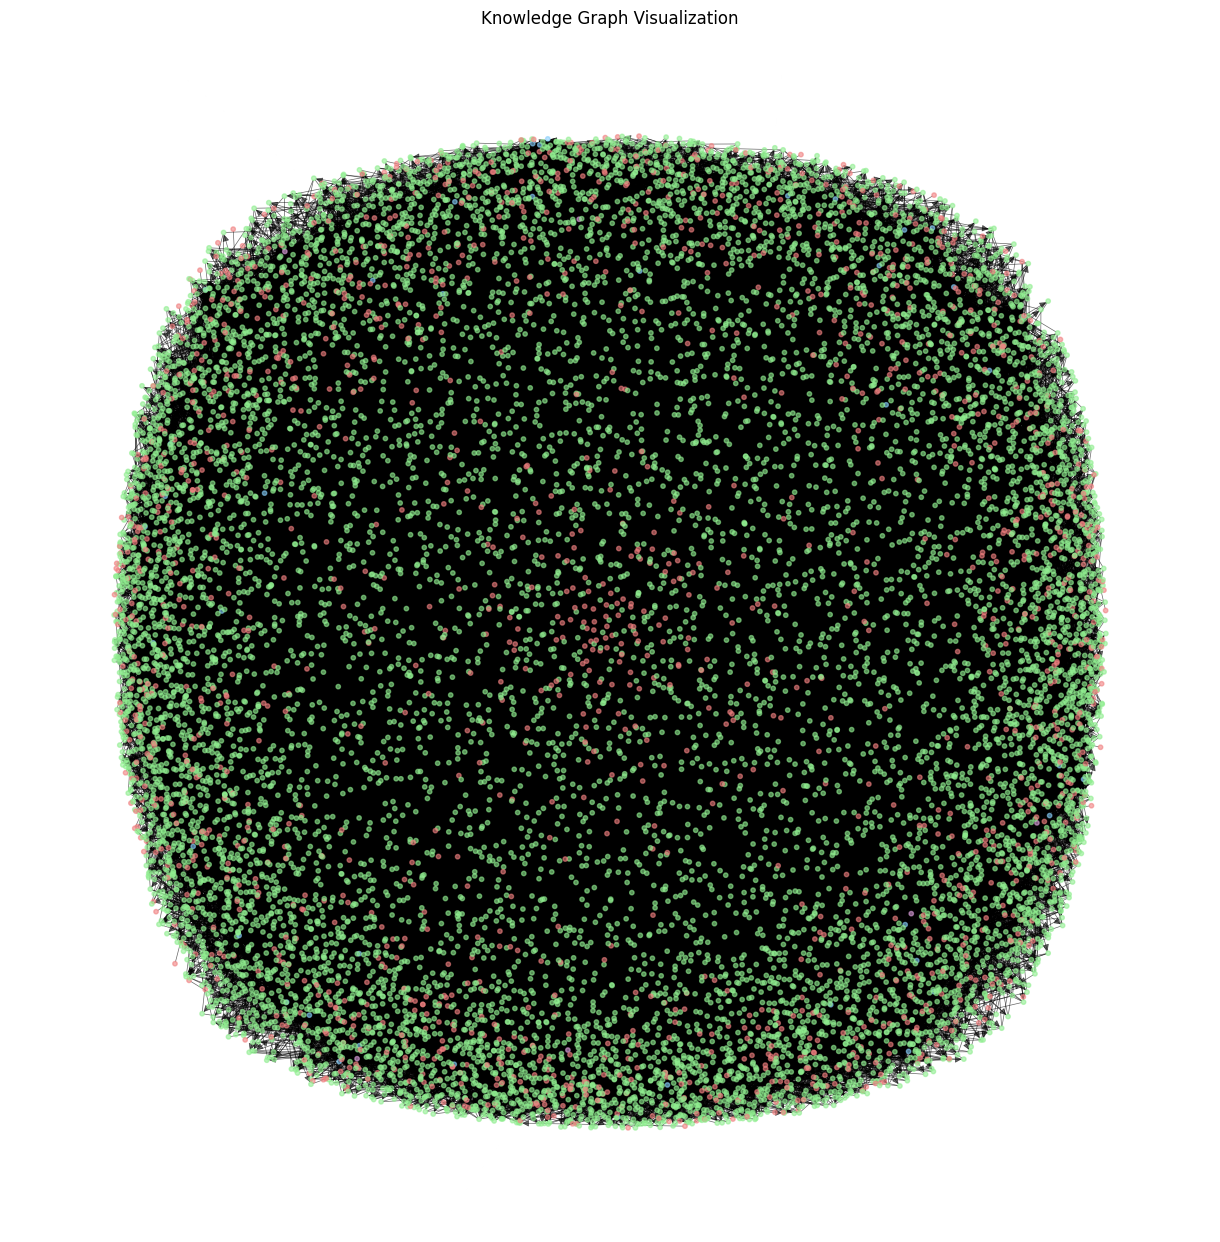

In [ ]:
# prompt: plot entire knowledge graph. give the color of node separately for anime, genre, type and user nodes

import matplotlib.pyplot as plt
import random

# Assuming 'G' is your NetworkX graph from the previous code

plt.figure(figsize=(12, 12))  # Adjust figure size as needed
pos = nx.spring_layout(G, k=0.15, iterations=20) # Adjust k and iterations for better layout

node_colors = []
for node in G.nodes():
    if node.startswith("user_"):
        node_colors.append("lightcoral")  # Color for user nodes
    elif node.startswith("anime_"):
        node_colors.append("lightgreen")  # Color for anime nodes
    elif node.startswith("genre_"):
        node_colors.append("lightskyblue")  # Color for genre nodes
    elif node.startswith("type_"):
        node_colors.append("plum")  # Color for type nodes
    else:
        node_colors.append("gray")  # Default color for other nodes


nx.draw(G, pos, with_labels=False, node_size=10, font_size=8, node_color=node_colors, alpha=0.6, width=0.5)
plt.title("Knowledge Graph Visualization")
plt.show()


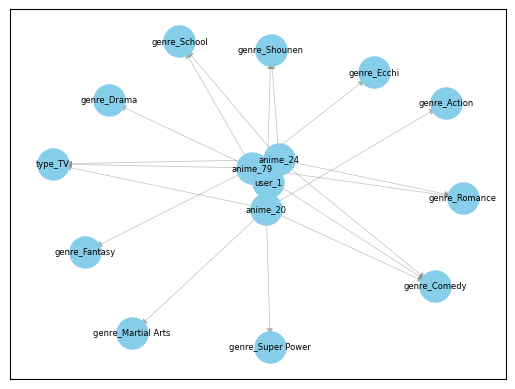

In [ ]:
import matplotlib.pyplot as plt

# Get a subgraph with a limited number of nodes and edges for visualization
subgraph = G.subgraph(list(G.nodes())[:15])  # Adjust the number as needed

pos = nx.spring_layout(subgraph) # positions for all nodes

# nodes
nx.draw_networkx_nodes(subgraph, pos, node_size=500, node_color="skyblue")

# edges
nx.draw_networkx_edges(subgraph, pos, edgelist=subgraph.edges(), width=0.5, alpha=0.5, edge_color="gray")

# labels
nx.draw_networkx_labels(subgraph, pos, font_size=6, font_family="sans-serif")

plt.show()

nx.spring_layout(): This function is a force-directed layout algorithm. Imagine nodes connected by springs. The algorithm simulates the forces between these springs to find an optimal layout where nodes are well-spaced and edges are relatively straight

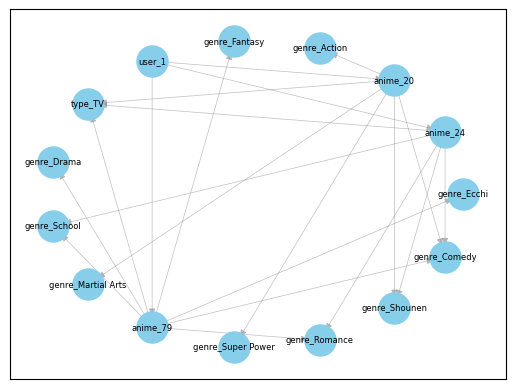

In [ ]:
import matplotlib.pyplot as plt

# Get a subgraph with a limited number of nodes and edges for visualization
subgraph = G.subgraph(list(G.nodes())[:15])  # Adjust the number as needed

pos = nx.circular_layout(subgraph) # positions for all nodes

# nodes
nx.draw_networkx_nodes(subgraph, pos, node_size=500, node_color="skyblue")

# edges
nx.draw_networkx_edges(subgraph, pos, edgelist=subgraph.edges(), width=0.5, alpha=0.5, edge_color="gray")

# labels
nx.draw_networkx_labels(subgraph, pos, font_size=6, font_family="sans-serif")

plt.show()

circular_layout: Arranges nodes in a circle. It's simple and effective for small graphs or when you want to emphasize the cyclical nature of connections.

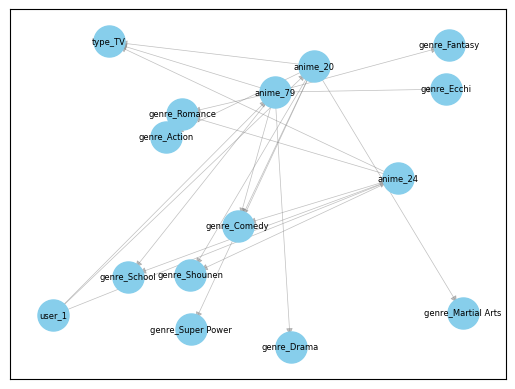

In [ ]:
import matplotlib.pyplot as plt

# Get a subgraph with a limited number of nodes and edges for visualization
subgraph = G.subgraph(list(G.nodes())[:15])  # Adjust the number as needed

pos = nx.random_layout(subgraph) # positions for all nodes

# nodes
nx.draw_networkx_nodes(subgraph, pos, node_size=500, node_color="skyblue")

# edges
nx.draw_networkx_edges(subgraph, pos, edgelist=subgraph.edges(), width=0.5, alpha=0.5, edge_color="gray")

# labels
nx.draw_networkx_labels(subgraph, pos, font_size=6, font_family="sans-serif")

plt.show()

random_layout: Positions nodes randomly within a given area. Useful for initial exploration or when other layouts fail to provide a satisfactory arrangement

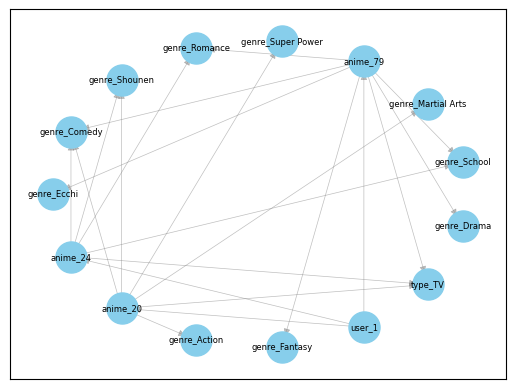

In [ ]:
import matplotlib.pyplot as plt

# Get a subgraph with a limited number of nodes and edges for visualization
subgraph = G.subgraph(list(G.nodes())[:15])  # Adjust the number as needed

pos = nx.shell_layout(subgraph) # positions for all nodes

# nodes
nx.draw_networkx_nodes(subgraph, pos, node_size=500, node_color="skyblue")

# edges
nx.draw_networkx_edges(subgraph, pos, edgelist=subgraph.edges(), width=0.5, alpha=0.5, edge_color="gray")

# labels
nx.draw_networkx_labels(subgraph, pos, font_size=6, font_family="sans-serif")

plt.show()

shell_layout: Places nodes in concentric circles or shells. Suitable for graphs with a hierarchical or layered structure

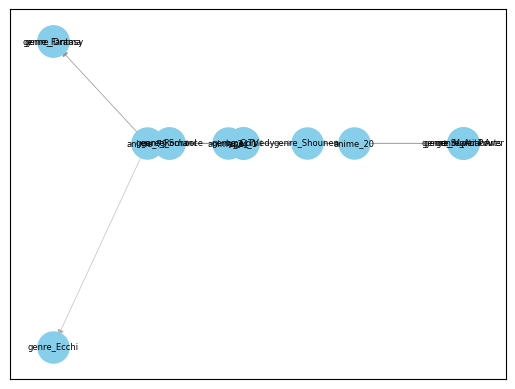

In [ ]:
import matplotlib.pyplot as plt

# Get a subgraph with a limited number of nodes and edges for visualization
subgraph = G.subgraph(list(G.nodes())[:15])  # Adjust the number as needed

pos = nx.spectral_layout(subgraph) # positions for all nodes

# nodes
nx.draw_networkx_nodes(subgraph, pos, node_size=500, node_color="skyblue")

# edges
nx.draw_networkx_edges(subgraph, pos, edgelist=subgraph.edges(), width=0.5, alpha=0.5, edge_color="gray")

# labels
nx.draw_networkx_labels(subgraph, pos, font_size=6, font_family="sans-serif")

plt.show()

spectral_layout: Uses the eigenvectors of the graph's Laplacian matrix to determine node positions. Often produces visually appealing layouts with well-distributed nodes.

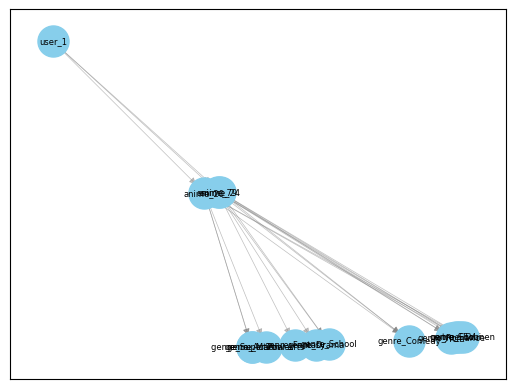

In [ ]:
import matplotlib.pyplot as plt

# Get a subgraph with a limited number of nodes and edges for visualization
subgraph = G.subgraph(list(G.nodes())[:15])  # Adjust the number as needed

pos = nx.kamada_kawai_layout(subgraph) # positions for all nodes

# nodes
nx.draw_networkx_nodes(subgraph, pos, node_size=500, node_color="skyblue")

# edges
nx.draw_networkx_edges(subgraph, pos, edgelist=subgraph.edges(), width=0.5, alpha=0.5, edge_color="gray")

# labels
nx.draw_networkx_labels(subgraph, pos, font_size=6, font_family="sans-serif")

plt.show()

kamada_kawai_layout: A force-directed layout similar to spring_layout but tends to produce more compact and aesthetically pleasing visualizations.

In [ ]:
# Step 3: Embed the Graph with PyKEEN
from pykeen.triples import TriplesFactory

# Convert NetworkX graph to triples
triples = []
for u, v, data in G.edges(data=True):
  triples.append((u, data['relation'], v))


In [ ]:
# Convert the list of tuples to a NumPy array
triples = np.array(triples) # This line is the key change

# Create a TriplesFactory for PyKEEN
triples_factory = TriplesFactory.from_labeled_triples(triples, create_inverse_triples=True)

In [ ]:
triples

array([['user_1', 'rated', 'anime_20'],
       ['user_1', 'rated', 'anime_24'],
       ['user_1', 'rated', 'anime_79'],
       ...,
       ['anime_30738', 'belongs_to', 'genre_Adventure'],
       ['anime_30738', 'belongs_to', 'genre_Kids'],
       ['anime_30738', 'has_type', 'type_Movie']], dtype='<U19')

In [ ]:
training_factory, testing_factory = triples_factory.split(ratios=[0.8, 0.2], random_state=42)

INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [31997, 11212]


In [ ]:
result = pipeline(
    model='RotatE',
    training=training_factory,
    testing=testing_factory,
    epochs=200,
    loss='marginranking',
    model_kwargs={'embedding_dim': 100, 'regularizer': 'lp', 'regularizer_kwargs': {'p': 2, 'weight': 1e-5}},  # Use 'lp' with p=2 for L2 regularization
)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.triples.triples_factory:Creating inverse triples.


Training epochs on cpu:   0%|          | 0/200 [00:00<?, ?epoch/s]

INFO:pykeen.triples.triples_factory:Creating inverse triples.


Training batches on cpu:   0%|          | 0/351 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/351 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0/351 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/351 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/351 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/11.2k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 1086.32s seconds


In [ ]:
# Step 4: Use the Embedding Model for Recommendations
# Example: Find similar anime for 'anime_101'
import torch

# Get the entity ID using the triples_factory
entity_id = triples_factory.entity_to_id['anime_24']

# Get the entity embedding
anime_embedding = result.model.entity_representations[0](torch.tensor([entity_id]))

similarities = {}
for entity_id, entity_embedding in enumerate(result.model.entity_representations[0](torch.arange(triples_factory.num_entities))):
    similarities[triples_factory.entity_id_to_label[entity_id]] = torch.norm(anime_embedding - entity_embedding).item()

# Sort and display top recommendations
recommendations = sorted(similarities.items(), key=lambda x: x[1])[:10]
print("Top recommendations:", recommendations)

Top recommendations: [('anime_24', 0.0), ('anime_18121', 2.1736013889312744), ('anime_24415', 2.3494982719421387), ('anime_9863', 2.6112613677978516), ('anime_16011', 2.7220184803009033), ('anime_11843', 2.750086545944214), ('anime_30230', 2.8071248531341553), ('anime_32228', 2.8401057720184326), ('anime_8525', 2.8685576915740967), ('anime_24417', 2.892939805984497)]


In [ ]:
# Function to get anime name from anime_id
def get_anime_name(anime_id):
    try:
        anime_id_int = int(anime_id.split('_')[1]) # Extract ID number from string like 'anime_123'
        name = df[df['anime_id'] == anime_id_int]['name'].iloc[0]
        return name
    except (IndexError, ValueError, AttributeError):
        return "Anime not found" # Handle cases where the anime_id is not in the DataFrame


# Print recommendations with anime names
for anime_id, similarity in recommendations:
    anime_name = get_anime_name(anime_id)
    print(f"{anime_id}   {anime_name}   : {similarity}")

anime_24   School Rumble   : 0.0
anime_18121   Teekyuu 2   : 2.1736013889312744
anime_24415   Kuroko no Basket 3rd Season   : 2.3494982719421387
anime_9863   SKET Dance   : 2.6112613677978516
anime_16011   Tokyo Ravens   : 2.7220184803009033
anime_11843   Danshi Koukousei no Nichijou   : 2.750086545944214
anime_30230   Diamond no Ace: Second Season   : 2.8071248531341553
anime_32228   Teekyuu 7   : 2.8401057720184326
anime_8525   Kami nomi zo Shiru Sekai   : 2.8685576915740967
anime_24417   Maido! Urayasu Tekkin Kazoku   : 2.892939805984497


In [ ]:
# Create a DataFrame from the recommendations
recommendations_df = pd.DataFrame(recommendations, columns=['Anime ID', 'Similarity'])

# Add anime names to the DataFrame
recommendations_df['Anime Name'] = recommendations_df['Anime ID'].apply(get_anime_name)

# Display the DataFrame as a table
recommendations_df

,Anime ID,Similarity,Anime Name
0,anime_24,0.000000,School Rumble
1,anime_18121,2.173601,Teekyuu 2
2,anime_24415,2.349498,Kuroko no Basket 3rd Season
3,anime_9863,2.611261,SKET Dance
4,anime_16011,2.722018,Tokyo Ravens
5,anime_11843,2.750087,Danshi Koukousei no Nichijou
6,anime_30230,2.807125,Diamond no Ace: Second Season
7,anime_32228,2.840106,Teekyuu 7
8,anime_8525,2.868558,Kami nomi zo Shiru Sekai
9,anime_24417,2.892940,Maido! Urayasu Tekkin Kazoku


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Prepare data for NCF
user_ids = df['user_id'].unique()
anime_ids = df['anime_id'].unique()
num_users = len(user_ids)
num_animes = len(anime_ids)

user_to_index = {user_id: index for index, user_id in enumerate(user_ids)}
anime_to_index = {anime_id: index for index, anime_id in enumerate(anime_ids)}

df['user_index'] = df['user_id'].map(user_to_index)
df['anime_index'] = df['anime_id'].map(anime_to_index)

# Split data into training and testing sets
X = df[['user_index', 'anime_index']].values
y = df['rating'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Define NCF model with KG embeddings
from tensorflow.keras.regularizers import l2
embedding_dim = 100 # Increased embedding dim to match Pykeen
user_input = Input(shape=(1,), name='user_input')
user_embedding = Embedding(num_users, embedding_dim, embeddings_regularizer=l2(1e-5), name='user_embedding')(user_input)
user_vec = Flatten(name='flatten_users')(user_embedding)
anime_input = Input(shape=(1,), name='anime_input')
anime_kg_embeddings = result.model.entity_representations[0](torch.arange(triples_factory.num_entities)).detach().numpy()
anime_kg_embedding_layer = Embedding(num_animes, embedding_dim, weights=[anime_kg_embeddings[:num_animes]], trainable=False, name='anime_kg_embedding')
anime_kg_vec = anime_kg_embedding_layer(anime_input)
anime_kg_vec = Flatten(name='flatten_anime_kg')(anime_kg_vec)

/usr/local/lib/python3.11/dist-packages/tensorflow/python/framework/constant_op.py:108: ComplexWarning: Casting complex values to real discards the imaginary part
  return ops.EagerTensor(value, ctx.device_name, dtype)


In [ ]:
merged = Concatenate()([user_vec, anime_kg_vec])
dense_1 = Dense(256, activation='relu', kernel_regularizer=l2(1e-5))(merged) # Increased neurons and L2 regularization
dense_2 = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(dense_1) # Added another layer
dense_3 = Dense(64, activation='relu', kernel_regularizer=l2(1e-5))(dense_2) # Added another layer
output = Dense(1)(dense_3)

In [ ]:
model = Model(inputs=[user_input, anime_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=0.00001), loss='mse') # Lower learning rate

In [ ]:
# Train the model with early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) # Increased patience

history = model.fit(
    [X_train[:, 0], X_train[:, 1]], y_train,
    epochs=500,  # Increased epochs
    batch_size=128, # Increased batch size
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1)

Epoch 1/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 38.8717 - val_loss: 37.2444
Epoch 2/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 37.6217 - val_loss: 35.8751
Epoch 3/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 35.7280 - val_loss: 34.4215
Epoch 4/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 34.5853 - val_loss: 32.8547
Epoch 5/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 33.1237 - val_loss: 31.1633
Epoch 6/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 31.6432 - val_loss: 29.3418
Epoch 7/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 29.2527 - val_loss: 27.3973
Epoch 8/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 27.3974 - val_loss: 25.3358
Epoch 9/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 25.3025 - val_loss: 23.1764
Epoch 10/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 23.0155 - val_loss: 20.9554
Epoch 11/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 20.4361 - val_loss: 18.6928
Epoch 12/500
63/63 ━━━━━━━━━━━━━

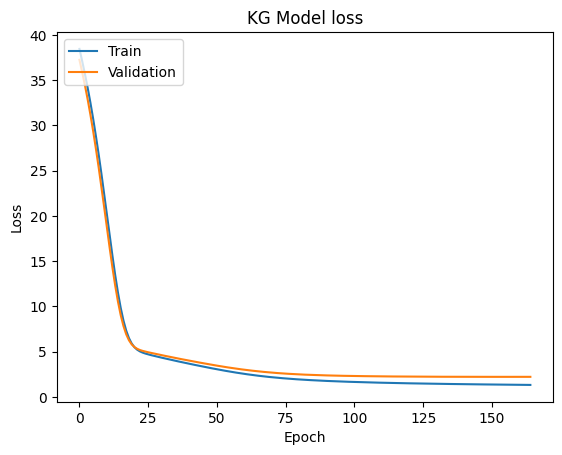

In [ ]:
# prompt: plot between train loss and validation loss

import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('KG Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import math
# Evaluate the model
loss = model.evaluate([X_test[:, 0], X_test[:, 1]], y_test)
print(f'Test Loss: {loss}')

# Predict ratings and calculate RMSE and MAE
y_pred = model.predict([X_test[:, 0], X_test[:, 1]])
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4758
Test Loss: 2.2583234310150146
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
RMSE: 1.5005600996175017
MAE: 1.0579954385757446


In [ ]:
from sklearn.metrics import accuracy_score
# Assuming y_test contains true ratings and y_pred contains predicted ratings
# Convert predicted ratings to classes (e.g., using a threshold)
y_pred_classes = (y_pred > 5).astype(int) # Example: Classify as positive (1) if prediction > 5
y_test_classes = (y_test > 5).astype(int)
#Calculate accuracy
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8110165696372593


In [ ]:
def recommend_anime(user_id, top_n=10):
  # Get the user's preferred genres and average rating.
  user_ratings = df[df['user_id'] == user_id]
  user_avg_rating = user_ratings['rating'].mean()
  user_genres = user_ratings['genre'].str.split(',').explode().value_counts()

  # Filter anime based on the user's preferences.
  recommended_anime = df[~df['anime_id'].isin(user_ratings['anime_id'])]  # Exclude anime already rated by user
  recommended_anime = recommended_anime[recommended_anime['rating'] >= user_avg_rating]
  recommended_anime = recommended_anime[recommended_anime['genre'].str.contains('|'.join(user_genres.index[:3]))]

  # Sort the recommendations by rating and return the top N.
  recommended_anime = recommended_anime.groupby('name')['rating'].mean().sort_values(ascending=False).head(top_n).index.tolist()

  return recommended_anime

# Define recommend_anime_with_details outside of recommend_anime
def recommend_anime_with_details(user_id, top_n=10):

    recommendations = recommend_anime(user_id, top_n)

    recommended_anime_data = []
    for anime_name in recommendations:
      anime_row = df[df['name'] == anime_name].iloc[0]
      recommended_anime_data.append({'Name': anime_name,'Genre': anime_row['genre'],'Rating': anime_row['rating']})

    return pd.DataFrame(recommended_anime_data)

# Example usage
user_id_to_recommend = 1
recommendations_with_details = recommend_anime_with_details(user_id_to_recommend)
recommendations_with_details

,Name,Genre,Rating
0,Seitokaichou ni Chuukoku,"Comedy, Drama, Romance, School, Yaoi",10
1,Seihou Bukyou Outlaw Star,"Action, Adventure, Comedy, Sci-Fi, Space",10
2,Weiß Kreuz OVA,"Action, Drama",10
3,Keroro Gunsou: Mushakero Ohirome Sengoku Ranst...,"Action, Comedy, Mecha, Parody, Samurai, Shounen",10
4,Keroro Gunsou: KeroZero Shupattsudayo! Zeninsh...,"Action, Adventure, Comedy, Mecha, Shounen, Space",10
5,Keroro Gunsou Movie 2: Shinkai no Princess de ...,"Action, Adventure, Comedy, Drama, Sci-Fi, Shounen",10
6,Katte ni Kaizou Specials,"Comedy, Parody, School, Sci-Fi, Shounen",10
7,Tokimeki Tonight,"Comedy, Fantasy, Romance, Shoujo, Vampire",10
8,Ochame na Futago: Claire Gakuin Monogatari,"Comedy, Historical, Kids, School, Shoujo, Slic...",10
9,Detroit Metal City: Birth of the Metal Devil,"Comedy, Music, Parody, Romance",10


In [ ]:
# prompt: using the model recommend anime

def recommend_anime_ncf(user_id, top_n=10):
    user_index = user_to_index.get(user_id)
    if user_index is None:
        print(f"User {user_id} not found in the dataset.")
        return []

    # Predict ratings for all anime for the given user
    anime_indices = np.array(list(range(num_animes)))
    user_indices = np.full(num_animes, user_index)
    predicted_ratings = model.predict([user_indices, anime_indices])

    # Get the top N recommendations
    top_anime_indices = np.argsort(predicted_ratings.flatten())[::-1][:top_n]
    recommendations = []

    for anime_index in top_anime_indices:
      anime_id = anime_ids[anime_index]
      anime_name = df[df['anime_id'] == anime_id]['name'].iloc[0]
      recommendations.append((anime_id, anime_name, predicted_ratings[anime_index][0]))

    return recommendations

# Example usage
user_id_to_recommend = 1  # Replace with the desired user ID
recommendations = recommend_anime_ncf(user_id_to_recommend)

# Print recommendations
print(f"Top {len(recommendations)} recommendations for user {user_id_to_recommend}:")
for anime_id, anime_name, predicted_rating in recommendations:
    print(f"- {anime_name} (Anime ID: {anime_id}, Predicted Rating: {predicted_rating:.2f})")

349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Top 10 recommendations for user 1:
- Kuro no Danshou (Anime ID: 220, Predicted Rating: 2.59)
- Juubee-chan 2: Siberia Yagyuu no Gyakushuu (Anime ID: 636, Predicted Rating: 2.48)
- Kyou no 5 no 2 (Anime ID: 837, Predicted Rating: 2.44)
- Kaze no Tairiku (Anime ID: 1777, Predicted Rating: 2.39)
- I&#039;&#039;s Pure (Anime ID: 811, Predicted Rating: 2.38)
- Ghost in the Shell: Stand Alone Complex 2nd GIG - Individual Eleven (Anime ID: 2448, Predicted Rating: 2.38)
- Tenkuu no Shiro Laputa (Anime ID: 513, Predicted Rating: 2.34)
- Captain Tsubasa: Asu ni Mukatte Hashire! (Anime ID: 2120, Predicted Rating: 2.30)
- Kuromukuro (Anime ID: 32245, Predicted Rating: 2.29)
- Captain Tsubasa: Europe Daikessen (Anime ID: 2118, Predicted Rating: 2.26)


In [ ]:
# Create a DataFrame from the recommendations
recommendations_df = pd.DataFrame(recommendations, columns=['Anime ID', 'Anime Name', 'Predicted Rating'])

# Display the DataFrame as a table
recommendations_df

,Anime ID,Anime Name,Predicted Rating
0,220,Kuro no Danshou,2.587132
1,636,Juubee-chan 2: Siberia Yagyuu no Gyakushuu,2.478503
2,837,Kyou no 5 no 2,2.442501
3,1777,Kaze no Tairiku,2.388309
4,811,I&#039;&#039;s Pure,2.382708
5,2448,Ghost in the Shell: Stand Alone Complex 2nd GI...,2.379331
6,513,Tenkuu no Shiro Laputa,2.340275
7,2120,Captain Tsubasa: Asu ni Mukatte Hashire!,2.302342
8,32245,Kuromukuro,2.293368
9,2118,Captain Tsubasa: Europe Daikessen,2.262955


In [ ]:
# Drop the 'Predicted Rating' column from the dataframe.
recommendations_df = recommendations_df.drop(columns=['Predicted Rating'])
# Display the modified dataframe (optional).
recommendations_df


,Anime ID,Anime Name
0,220,Kuro no Danshou
1,636,Juubee-chan 2: Siberia Yagyuu no Gyakushuu
2,837,Kyou no 5 no 2
3,1777,Kaze no Tairiku
4,811,I&#039;&#039;s Pure
5,2448,Ghost in the Shell: Stand Alone Complex 2nd GI...
6,513,Tenkuu no Shiro Laputa
7,2120,Captain Tsubasa: Asu ni Mukatte Hashire!
8,32245,Kuromukuro
9,2118,Captain Tsubasa: Europe Daikessen


In [ ]:
# prompt: calculate mae, mse and rmse of the model

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

RMSE: 1.5005600996175017
MAE: 1.0579954385757446
